#  Formula 1 ML Project
**Course:** Machine Learning — Prof. Fahd Kalloubi  
**Dataset:** results.csv — F1 Complete History 1950–2026  
**Goals:** Visualiser les données F1, appliquer des algorithmes ML, et prédire les résultats 2026
### Etudiant:Bounhar ElMahjoub 
### Apogee:2330686
### ISI-S6

## 1. Imports & Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, AdaBoostClassifier
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (confusion_matrix, f1_score, roc_auc_score, roc_curve,
                              mean_absolute_error, mean_squared_error, r2_score,
                              ConfusionMatrixDisplay)
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage
import warnings
warnings.filterwarnings('ignore')

# Style
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.family'] = 'DejaVu Sans'
COLORS = ['#e10600','#1f77b4','#2ca02c','#ff7f0e','#9467bd','#8c564b']
sns.set_style('whitegrid')

print("imports passe ")

The imports done 


## 2. Chargement & Nettoyage des Donnees

In [3]:
df_raw = pd.read_csv('results.csv')
df_raw.replace('\\N', np.nan, inplace=True)

# Auto-detect column names (works with both old and new Kaggle versions)
POS_COL    = 'positionOrder' if 'positionOrder' in df_raw.columns else 'position'
RANK_COL   = next((c for c in ['rank','fastestLapRank','fastest_lap_rank'] if c in df_raw.columns), None)
SPEED_COL  = next((c for c in ['fastestLapSpeed','fastest_lap_speed'] if c in df_raw.columns), None)
STATUS_COL = 'statusId' if 'statusId' in df_raw.columns else 'status'

for col in [POS_COL, 'grid', 'points', 'laps', RANK_COL, SPEED_COL]:
    if col and col in df_raw.columns:
        df_raw[col] = pd.to_numeric(df_raw[col], errors='coerce')

df_raw.dropna(subset=[POS_COL, 'grid'], inplace=True)

print(f" Shape: {df_raw.shape}")
print(f" Saisons: {df_raw['season'].min()} → {df_raw['season'].max()}")
print(f" POS_COL={POS_COL} | RANK_COL={RANK_COL} | STATUS_COL={STATUS_COL}")
print(f"Colonnes: {list(df_raw.columns)}")
df_raw.head()

 Shape: (25939, 15)
 Saisons: 1950 → 2026
 POS_COL=position | RANK_COL=fastest_lap_rank | STATUS_COL=status
Colonnes: ['season', 'round', 'race_name', 'driver_id', 'driver_name', 'constructor_id', 'constructor', 'grid', 'position', 'points', 'laps', 'status', 'time', 'fastest_lap', 'fastest_lap_rank']


,season,round,race_name,driver_id,driver_name,constructor_id,constructor,grid,position,points,laps,status,time,fastest_lap,fastest_lap_rank
0,1950,1,British Grand Prix,farina,Nino Farina,alfa,Alfa Romeo,1,1,9.0,70,Finished,2:13:23.600,NaN,NaN
1,1950,1,British Grand Prix,fagioli,Luigi Fagioli,alfa,Alfa Romeo,2,2,6.0,70,Finished,+2.600,NaN,NaN
2,1950,1,British Grand Prix,reg_parnell,Reg Parnell,alfa,Alfa Romeo,4,3,4.0,70,Finished,+52.000,NaN,NaN
3,1950,1,British Grand Prix,cabantous,Yves Cabantous,lago,Talbot-Lago,6,4,3.0,68,+2 Laps,NaN,NaN,NaN
4,1950,1,British Grand Prix,rosier,Louis Rosier,lago,Talbot-Lago,9,5,2.0,68,+2 Laps,NaN,NaN,NaN


## 3. Exploration des Donnees 

In [4]:
# ── 3.1 Vue d'ensemble ───────────────────────────────────────
print("=== INFORMATIONS GENERALES ===")
print(f"Courses totales   : {df_raw[['season','round']].drop_duplicates().shape[0]}")
print(f"Pilotes uniques   : {df_raw['driver_id'].nunique()}")
print(f"Constructeurs     : {df_raw['constructor_id'].nunique()}")
print(f"Entrées totales   : {len(df_raw)}")
print()
print("=== VALEURS MANQUANTES ===")
missing = df_raw.isnull().sum()
print(missing[missing > 0].to_string())

=== INFORMATIONS GENERALES ===
Courses totales   : 1152
Pilotes uniques   : 818
Constructeurs     : 205
Entrées totales   : 25939

=== VALEURS MANQUANTES ===
time                17585
fastest_lap         17154
fastest_lap_rank    17154


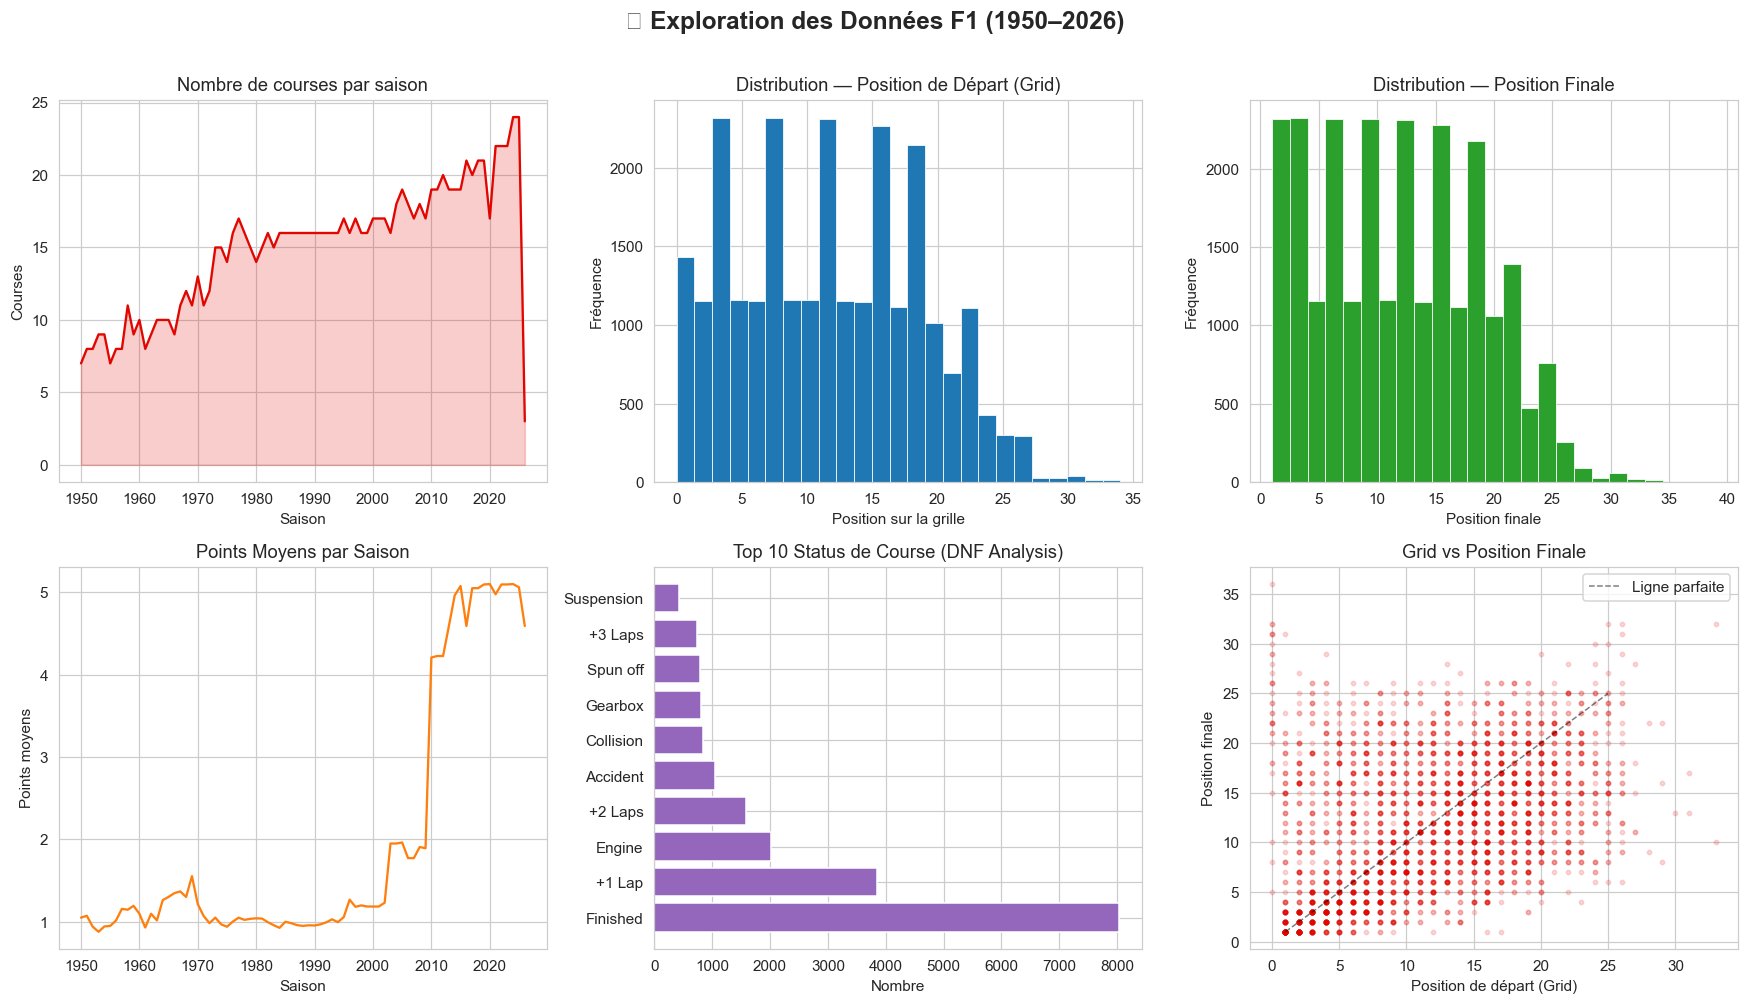

In [5]:
# ── 3.2 Visualisations EDA ───────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('📊 Exploration des Données F1 (1950–2026)', fontsize=16, fontweight='bold', y=1.01)

# A) Courses par saison
races_per_season = df_raw.groupby('season')['round'].max()
axes[0,0].plot(races_per_season.index, races_per_season.values, color=COLORS[0], linewidth=1.5)
axes[0,0].fill_between(races_per_season.index, races_per_season.values, alpha=0.2, color=COLORS[0])
axes[0,0].set_title('Nombre de courses par saison')
axes[0,0].set_xlabel('Saison'); axes[0,0].set_ylabel('Courses')

# B) Distribution position de depart (grid)
axes[0,1].hist(df_raw['grid'].dropna(), bins=25, color=COLORS[1], edgecolor='white', linewidth=0.5)
axes[0,1].set_title('Distribution — Position de Départ (Grid)')
axes[0,1].set_xlabel('Position sur la grille'); axes[0,1].set_ylabel('Fréquence')

# C) Distribution position finale
axes[0,2].hist(df_raw[POS_COL].dropna(), bins=25, color=COLORS[2], edgecolor='white', linewidth=0.5)
axes[0,2].set_title('Distribution — Position Finale')
axes[0,2].set_xlabel('Position finale'); axes[0,2].set_ylabel('Fréquence')

# D) Points par saison (moyenne)
avg_pts = df_raw.groupby('season')['points'].mean()
axes[1,0].plot(avg_pts.index, avg_pts.values, color=COLORS[3], linewidth=1.5)
axes[1,0].set_title('Points Moyens par Saison')
axes[1,0].set_xlabel('Saison'); axes[1,0].set_ylabel('Points moyens')

# E) Status distribution
status_counts = df_raw[STATUS_COL].value_counts().head(10)
axes[1,1].barh(status_counts.index.astype(str), status_counts.values, color=COLORS[4])
axes[1,1].set_title('Top 10 Status de Course (DNF Analysis)')
axes[1,1].set_xlabel('Nombre')

# F) Grid vs Position finale (scatter)
sample = df_raw.sample(min(3000, len(df_raw)), random_state=42)
axes[1,2].scatter(sample['grid'], sample[POS_COL], alpha=0.15, s=8, color=COLORS[0])
axes[1,2].plot([1,25],[1,25], 'k--', linewidth=1, alpha=0.5, label='Ligne parfaite')
axes[1,2].set_title('Grid vs Position Finale')
axes[1,2].set_xlabel('Position de départ (Grid)'); axes[1,2].set_ylabel('Position finale')
axes[1,2].legend()

plt.tight_layout()
plt.show()

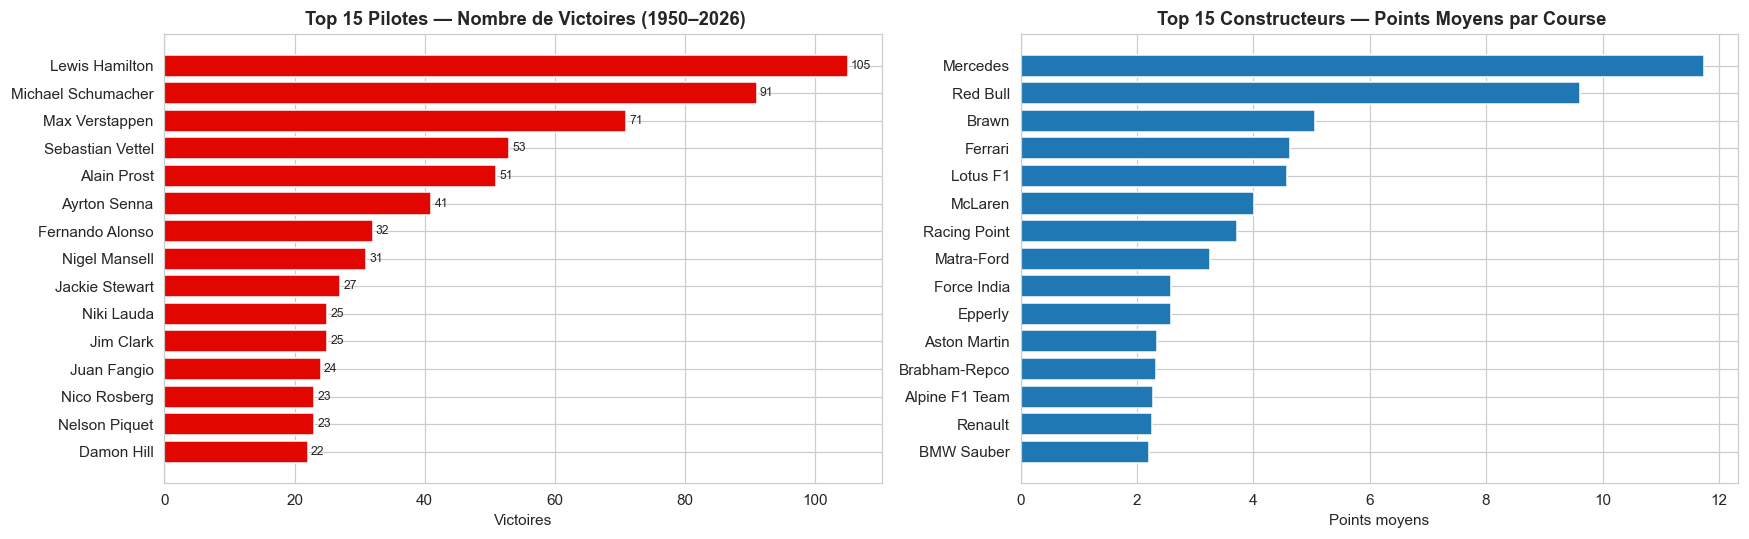

In [6]:
# ── 3.3 Top pilotes & constructeurs ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Top 15 pilotes par victoires
wins_by_driver = df_raw[df_raw[POS_COL]==1].groupby('driver_name').size().sort_values(ascending=True).tail(15)
axes[0].barh(wins_by_driver.index, wins_by_driver.values, color=COLORS[0])
axes[0].set_title(' Top 15 Pilotes — Nombre de Victoires (1950–2026)', fontweight='bold')
axes[0].set_xlabel('Victoires')
for i, v in enumerate(wins_by_driver.values):
    axes[0].text(v + 0.5, i, str(v), va='center', fontsize=8)

# Top 15 constructeurs par points moyens
avg_pts_constr = df_raw.groupby('constructor')['points'].mean().sort_values(ascending=True).tail(15)
axes[1].barh(avg_pts_constr.index, avg_pts_constr.values, color=COLORS[1])
axes[1].set_title(' Top 15 Constructeurs — Points Moyens par Course', fontweight='bold')
axes[1].set_xlabel('Points moyens')

plt.tight_layout()
plt.show()

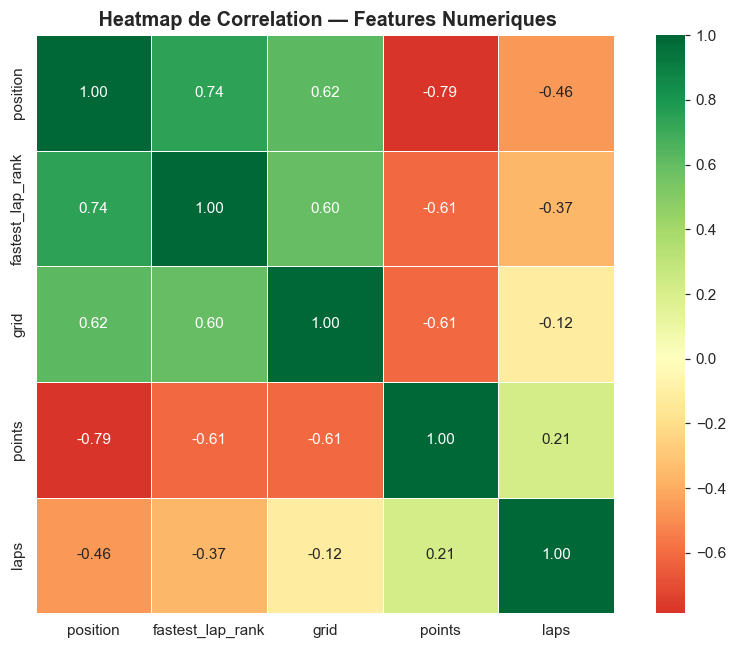

📌 Observation cle : La position de depart (grid) est fortement correlee a la position finale.


In [7]:
# ── 3.4 Heatmap de corrélation ───────────────────────────────
corr_cols = [c for c in [POS_COL, RANK_COL, SPEED_COL, 'grid', 'points', 'laps'] if c and c in df_raw.columns]
corr_data = df_raw[corr_cols].dropna()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_data.corr(), annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5, ax=ax, square=True)
ax.set_title(' Heatmap de Correlation — Features Numeriques', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("📌 Observation cle : La position de depart (grid) est fortement correlee a la position finale.")

## 4. Feature Engineering

In [8]:
# ── 4.1 Creation des features ────────────────────────────────
df = df_raw.copy()

# Target
df['is_winner'] = (df[POS_COL] == 1).astype(int)

# Finished or DNF
if STATUS_COL == 'statusId':
    df['finished'] = (df[STATUS_COL] == 1).astype(int)
else:
    df['finished'] = (df[STATUS_COL].str.lower() == 'finished').astype(int)

# Driver features (historical stats)
wins   = df[df['is_winner']==1].groupby('driver_id').size().rename('total_wins')
races  = df.groupby('driver_id').size().rename('total_races')
driver_stats = pd.concat([wins, races], axis=1).fillna(0)
driver_stats['driver_win_rate']   = driver_stats['total_wins'] / driver_stats['total_races']
driver_stats['driver_avg_finish'] = df.groupby('driver_id')[POS_COL].mean()
driver_stats['driver_avg_pts']    = df.groupby('driver_id')['points'].mean()

# Constructor feature
constructor_stats = df.groupby('constructor_id')['points'].mean().rename('constructor_avg_pts')

# Merge
df = df.merge(driver_stats[['driver_win_rate','driver_avg_finish','driver_avg_pts']], on='driver_id', how='left')
df = df.merge(constructor_stats, on='constructor_id', how='left')
df['grid_improvement'] = df['grid'] - df[POS_COL]

print(" Features creees :")
new_features = ['is_winner','finished','driver_win_rate','driver_avg_finish',
                'driver_avg_pts','constructor_avg_pts','grid_improvement']
for f in new_features:
    print(f"   • {f}: {df[f].describe().to_dict()}")

 Features creees :
   • is_winner: {'count': 25939.0, 'mean': 0.04452754539496511, 'std': 0.2062679891488916, 'min': 0.0, '25%': 0.0, '50%': 0.0, '75%': 0.0, 'max': 1.0}
   • finished: {'count': 25939.0, 'mean': 0.3097652183970084, 'std': 0.46240563471340285, 'min': 0.0, '25%': 0.0, '50%': 0.0, '75%': 1.0, 'max': 1.0}
   • driver_win_rate: {'count': 25939.0, 'mean': 0.04452754539496511, 'std': 0.07475907249034604, 'min': 0.0, '25%': 0.0, '50%': 0.011764705882352941, '75%': 0.05263157894736842, 'max': 0.5}
   • driver_avg_finish: {'count': 25939.0, 'mean': 11.935618181117237, 'std': 3.16646241541925, 'min': 2.0, '25%': 9.758620689655173, '50%': 11.75438596491228, '75%': 14.116666666666667, 'max': 38.0}
   • driver_avg_pts: {'count': 25939.0, 'mean': 2.1556139403986276, 'std': 2.803627123776974, 'min': 0.0, '25%': 0.2972972972972973, '50%': 1.1904761904761905, '75%': 2.536842105263158, 'max': 14.040254237288135}
   • constructor_avg_pts: {'count': 25939.0, 'mean': 2.155613940398628, 'std

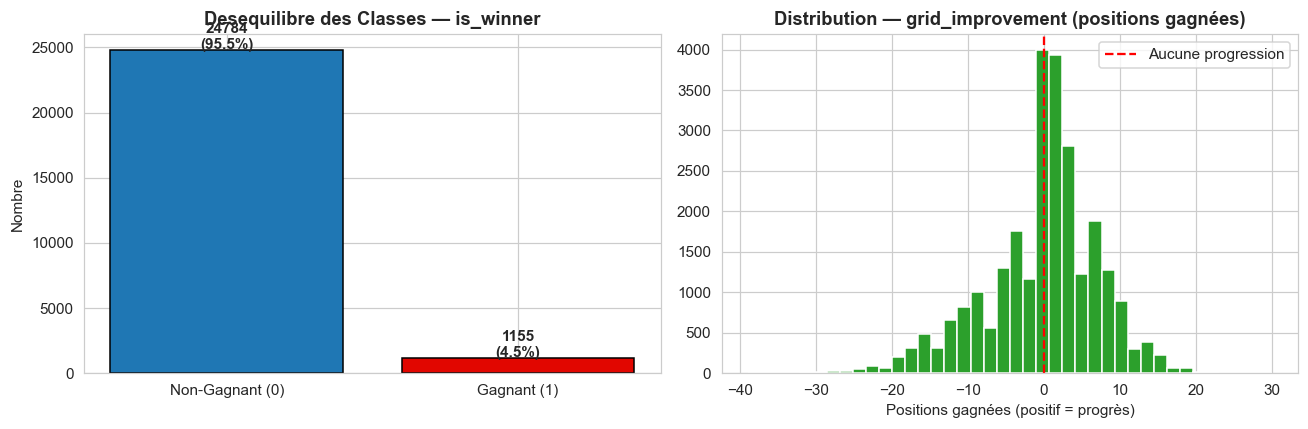


 Classes : 24784 non-gagnants (95.5%) vs 1155 gagnants (4.5%)
→ Utiliser AUC-ROC et F1 (pas Accuracy) à cause du déséquilibre.


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Class balance
counts = df['is_winner'].value_counts()
axes[0].bar(['Non-Gagnant (0)', 'Gagnant (1)'], counts.values, color=[COLORS[1], COLORS[0]], edgecolor='black')
axes[0].set_title('Desequilibre des Classes — is_winner', fontweight='bold')
axes[0].set_ylabel('Nombre')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 100, f'{v}\n({v/len(df)*100:.1f}%)', ha='center', fontweight='bold')

# Grid improvement distribution
axes[1].hist(df['grid_improvement'], bins=40, color=COLORS[2], edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5, label='Aucune progression')
axes[1].set_title('Distribution — grid_improvement (positions gagnées)', fontweight='bold')
axes[1].set_xlabel('Positions gagnées (positif = progrès)')
axes[1].legend()

plt.tight_layout()
plt.show()
print(f"\n Classes : {counts[0]} non-gagnants ({counts[0]/len(df)*100:.1f}%) vs {counts[1]} gagnants ({counts[1]/len(df)*100:.1f}%)")
print("→ Utiliser AUC-ROC et F1 (pas Accuracy) à cause du déséquilibre.")

## 5. Preprocessing — Train/Test Split

In [10]:
FEATURE_COLS = ['grid', 'laps', 'driver_win_rate', 'driver_avg_finish',
                'driver_avg_pts', 'constructor_avg_pts', 'grid_improvement', 'finished']

df_model = df.dropna(subset=FEATURE_COLS + [POS_COL]).copy()

df_train_full = df_model[df_model['season'] < 2026]
df_2026       = df_model[df_model['season'] == 2026]

X_all   = df_train_full[FEATURE_COLS]
y_class = df_train_full['is_winner']
y_reg   = df_train_full[POS_COL]

scaler   = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_all), columns=FEATURE_COLS)

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_scaled, y_class, test_size=0.2, random_state=42, stratify=y_class)
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_scaled, y_reg, test_size=0.2, random_state=42)

print(f" Donnees d'entrainement : {X_train_c.shape[0]} entrées (1950–2025)")
print(f" Données de test        : {X_test_c.shape[0]} entrées (80/20 split)")
print(f" Données 2026           : {len(df_2026)} entrées (3 courses)")
print(f" Features utilisées     : {FEATURE_COLS}")

 Donnees d'entrainement : 20698 entrées (1950–2025)
 Données de test        : 5175 entrées (80/20 split)
 Données 2026           : 66 entrées (3 courses)
 Features utilisées     : ['grid', 'laps', 'driver_win_rate', 'driver_avg_finish', 'driver_avg_pts', 'constructor_avg_pts', 'grid_improvement', 'finished']


## 6. Problème 1 — Classification : Qui va Gagner ?

In [11]:
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

classifiers = {
    'Decision Tree'      : DecisionTreeClassifier(max_depth=6, criterion='gini', class_weight='balanced', random_state=42),
    'KNN'                : KNeighborsClassifier(n_neighbors=11),
    'Random Forest'      : RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42),
    'AdaBoost'           : AdaBoostClassifier(n_estimators=150, learning_rate=0.5, random_state=42),
    'Logistic Regression': LogisticRegression(C=1.0, class_weight='balanced', max_iter=1000, random_state=42),
}

clf_results = {}
for name, clf in classifiers.items():
    clf.fit(X_train_c, y_train_c)
    y_pred  = clf.predict(X_test_c)
    y_proba = clf.predict_proba(X_test_c)[:,1]
    f1  = f1_score(y_test_c, y_pred)
    auc = roc_auc_score(y_test_c, y_proba)
    cv_auc = cross_val_score(clf, X_scaled, y_class, cv=skf, scoring='roc_auc').mean()
    clf_results[name] = {'f1': f1, 'auc': auc, 'cv_auc': cv_auc,
                         'y_pred': y_pred, 'y_proba': y_proba, 'model': clf}
    print(f"{name:22} | F1={f1:.3f} | AUC={auc:.3f} | CV-AUC={cv_auc:.3f}")

Decision Tree          | F1=0.752 | AUC=0.995 | CV-AUC=0.993
KNN                    | F1=0.553 | AUC=0.967 | CV-AUC=0.961
Random Forest          | F1=0.923 | AUC=0.998 | CV-AUC=0.999
AdaBoost               | F1=0.844 | AUC=0.993 | CV-AUC=0.992
Logistic Regression    | F1=0.744 | AUC=1.000 | CV-AUC=1.000


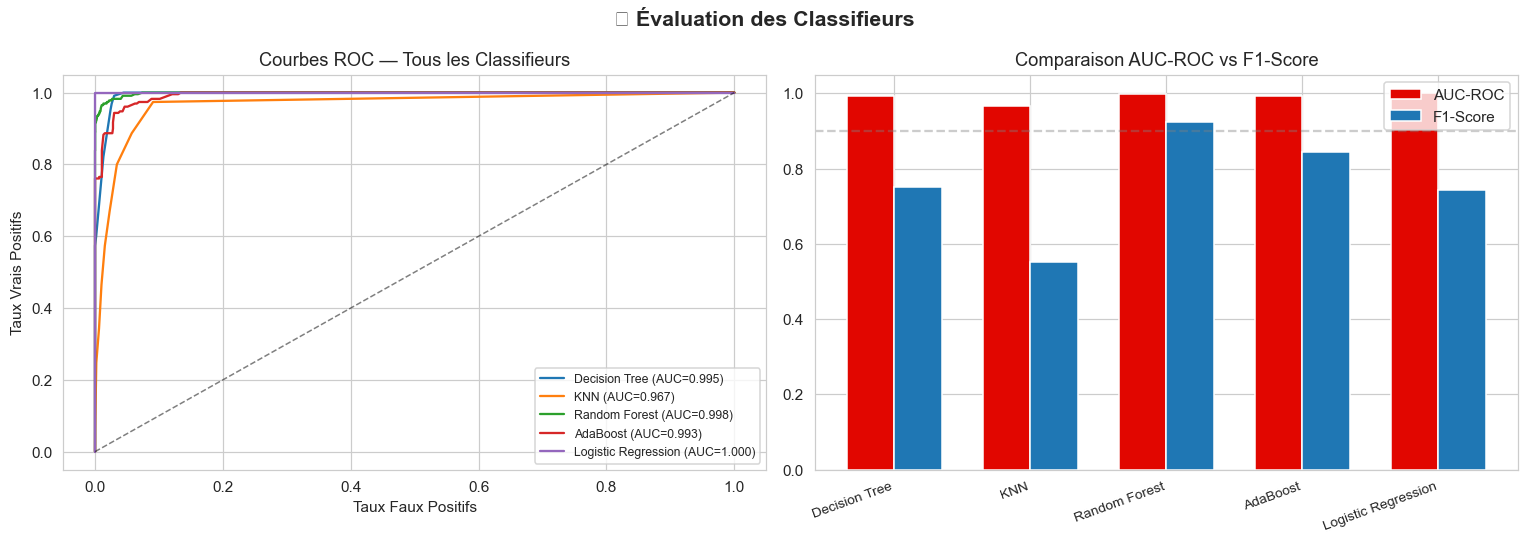

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('📊 Évaluation des Classifieurs', fontsize=14, fontweight='bold')

# ROC Curves
for i, (name, res) in enumerate(clf_results.items()):
    fpr, tpr, _ = roc_curve(y_test_c, res['y_proba'])
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={res['auc']:.3f})", linewidth=1.5)
axes[0].plot([0,1],[0,1],'k--', linewidth=1, alpha=0.5)
axes[0].set_title('Courbes ROC — Tous les Classifieurs')
axes[0].set_xlabel('Taux Faux Positifs'); axes[0].set_ylabel('Taux Vrais Positifs')
axes[0].legend(fontsize=8)

# Bar chart comparison
names = list(clf_results.keys())
aucs  = [clf_results[n]['auc'] for n in names]
f1s   = [clf_results[n]['f1'] for n in names]
x = np.arange(len(names))
w = 0.35
axes[1].bar(x - w/2, aucs, w, label='AUC-ROC', color=COLORS[0])
axes[1].bar(x + w/2, f1s,  w, label='F1-Score', color=COLORS[1])
axes[1].set_title('Comparaison AUC-ROC vs F1-Score')
axes[1].set_xticks(x); axes[1].set_xticklabels(names, rotation=20, ha='right', fontsize=9)
axes[1].set_ylim(0, 1.05); axes[1].legend()
axes[1].axhline(0.9, color='gray', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

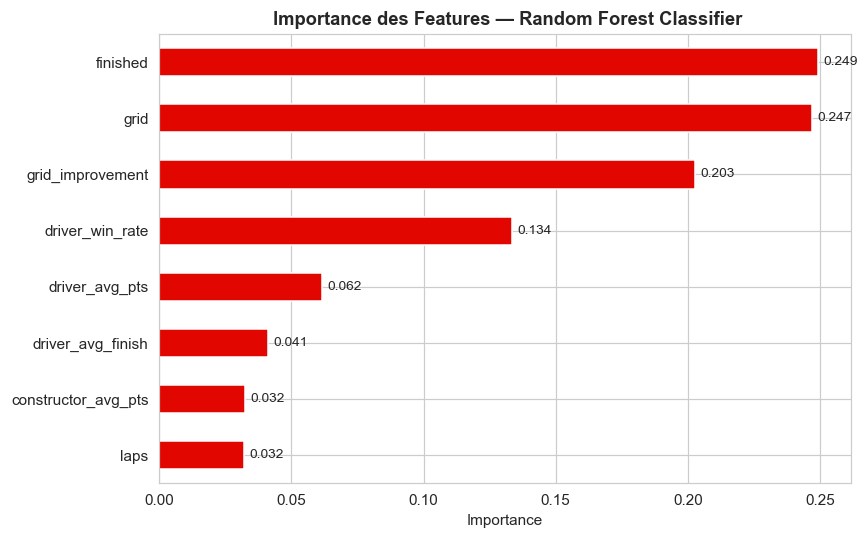

In [13]:
# ── 6.3 Feature Importance (Random Forest) ───────────────────
rf_clf = clf_results['Random Forest']['model']
fi = pd.Series(rf_clf.feature_importances_, index=FEATURE_COLS).sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
fi.plot(kind='barh', ax=ax, color=COLORS[0])
ax.set_title(' Importance des Features — Random Forest Classifier', fontweight='bold')
ax.set_xlabel('Importance')
for i, v in enumerate(fi.values):
    ax.text(v + 0.002, i, f'{v:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

## 7. Problème 2 — Régression : Prédire la Position Finale

In [14]:
regressors = {
    'Ridge Regression'        : Ridge(alpha=1.0),
    'Decision Tree Regressor' : DecisionTreeRegressor(max_depth=8, random_state=42),
    'Random Forest Regressor' : RandomForestRegressor(n_estimators=200, random_state=42),
}

reg_results = {}
for name, reg in regressors.items():
    reg.fit(X_train_r, y_train_r)
    y_pred = reg.predict(X_test_r)
    mae  = mean_absolute_error(y_test_r, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_r, y_pred))
    r2   = r2_score(y_test_r, y_pred)
    reg_results[name] = {'mae': mae, 'rmse': rmse, 'r2': r2, 'y_pred': y_pred, 'model': reg}
    print(f"{name:26} | MAE={mae:.2f} pos | RMSE={rmse:.2f} | R²={r2:.3f}")

Ridge Regression           | MAE=0.00 pos | RMSE=0.00 | R²=1.000
Decision Tree Regressor    | MAE=1.08 pos | RMSE=1.57 | R²=0.948
Random Forest Regressor    | MAE=0.07 pos | RMSE=0.28 | R²=0.998


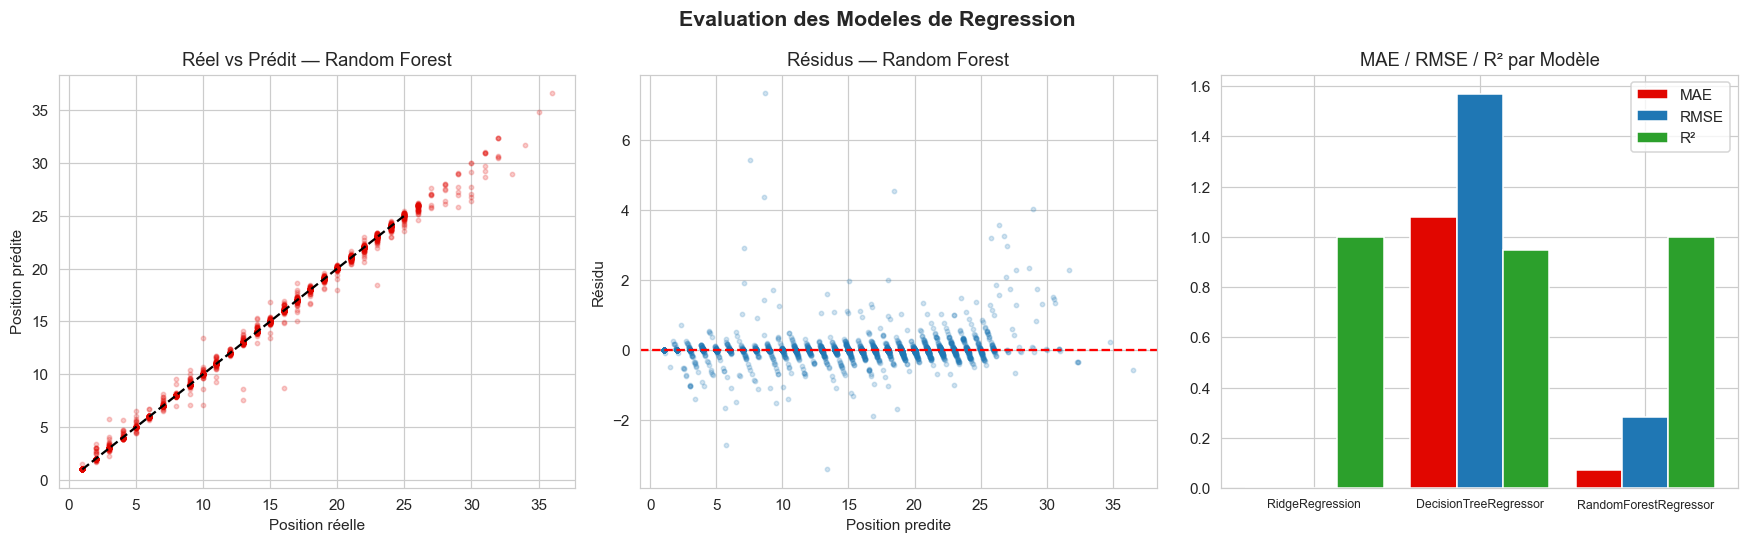

In [15]:
# ── 7.2 Visualisation des résultats de régression ────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(' Evaluation des Modeles de Regression', fontsize=14, fontweight='bold')

# Actual vs Predicted (RF)
rf_reg_model = reg_results['Random Forest Regressor']['model']
y_pred_rf = reg_results['Random Forest Regressor']['y_pred']

axes[0].scatter(y_test_r, y_pred_rf, alpha=0.2, s=8, color=COLORS[0])
axes[0].plot([1,25],[1,25],'k--', linewidth=1.5)
axes[0].set_title('Réel vs Prédit — Random Forest')
axes[0].set_xlabel('Position réelle'); axes[0].set_ylabel('Position prédite')

# Residuals
residuals = y_test_r.values - y_pred_rf
axes[1].scatter(y_pred_rf, residuals, alpha=0.2, s=8, color=COLORS[1])
axes[1].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_title('Résidus — Random Forest')
axes[1].set_xlabel('Position predite'); axes[1].set_ylabel('Résidu')

# Metrics bar chart
names_r = list(reg_results.keys())
maes  = [reg_results[n]['mae']  for n in names_r]
rmses = [reg_results[n]['rmse'] for n in names_r]
r2s   = [reg_results[n]['r2']   for n in names_r]
x = np.arange(len(names_r)); w = 0.28
axes[2].bar(x - w, maes,  w, label='MAE',  color=COLORS[0])
axes[2].bar(x,     rmses, w, label='RMSE', color=COLORS[1])
axes[2].bar(x + w, r2s,   w, label='R²',   color=COLORS[2])
axes[2].set_xticks(x)
axes[2].set_xticklabels([n.replace(' ','') for n in names_r], fontsize=8)
axes[2].set_title('MAE / RMSE / R² par Modèle')
axes[2].legend()

plt.tight_layout()
plt.show()

## 8. Problème 3 — Clustering : Archétypes de Pilotes

In [16]:
min_races = 10
driver_profiles = df.groupby('driver_name').agg(
    races       = (POS_COL, 'count'),
    wins        = ('is_winner', 'sum'),
    avg_pos     = (POS_COL, 'mean'),
    avg_pts     = ('points', 'mean'),
    win_rate    = ('is_winner', 'mean'),
    dnf_rate    = ('finished', lambda x: 1 - x.mean()),
    avg_grid    = ('grid', 'mean'),
    grid_improv = ('grid_improvement', 'mean')
).query(f'races >= {min_races}')

CLUSTER_FEATURES = ['win_rate','avg_pos','avg_pts','dnf_rate','avg_grid','grid_improv']
X_cluster = driver_profiles[CLUSTER_FEATURES].dropna()
scaler_c  = StandardScaler()
X_cluster_scaled = scaler_c.fit_transform(X_cluster)

print(f" {len(X_cluster)} pilotes avec ≥{min_races} courses inclus dans le clustering")

 356 pilotes avec ≥10 courses inclus dans le clustering


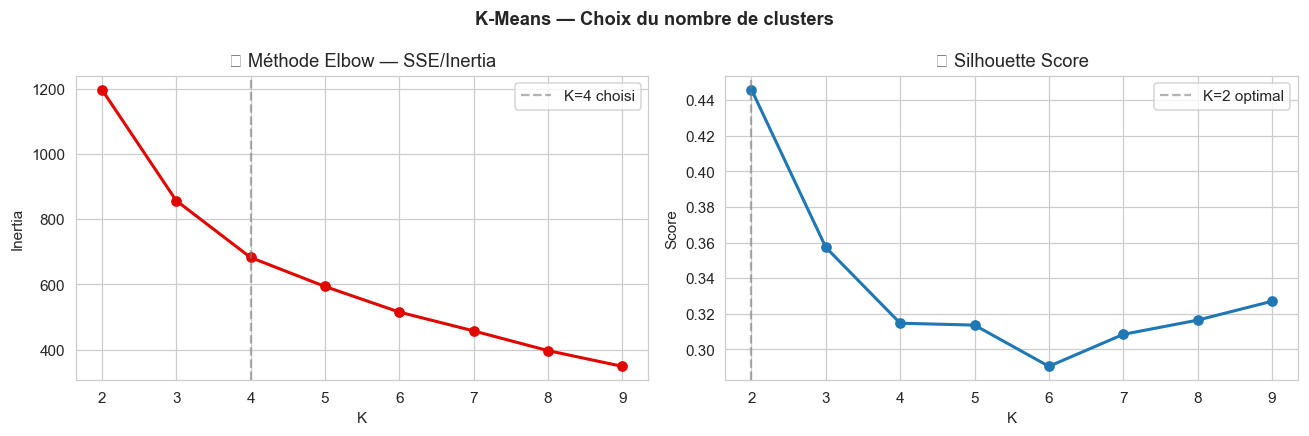

 Meilleur K par silhouette : 2


In [17]:
from sklearn.metrics import silhouette_score

inertias, silhouettes = [], []
K_range = range(2, 10)

for k in K_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(X_cluster_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_cluster_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(list(K_range), inertias, marker='o', color=COLORS[0], linewidth=2)
axes[0].set_title('📈 Méthode Elbow — SSE/Inertia'); axes[0].set_xlabel('K'); axes[0].set_ylabel('Inertia')
axes[0].axvline(4, color='gray', linestyle='--', alpha=0.6, label='K=4 choisi')
axes[0].legend()

axes[1].plot(list(K_range), silhouettes, marker='o', color=COLORS[1], linewidth=2)
axes[1].set_title('📈 Silhouette Score'); axes[1].set_xlabel('K'); axes[1].set_ylabel('Score')
best_k = list(K_range)[np.argmax(silhouettes)]
axes[1].axvline(best_k, color='gray', linestyle='--', alpha=0.6, label=f'K={best_k} optimal')
axes[1].legend()

plt.suptitle('K-Means — Choix du nombre de clusters', fontweight='bold')
plt.tight_layout()
plt.show()
print(f" Meilleur K par silhouette : {best_k}")

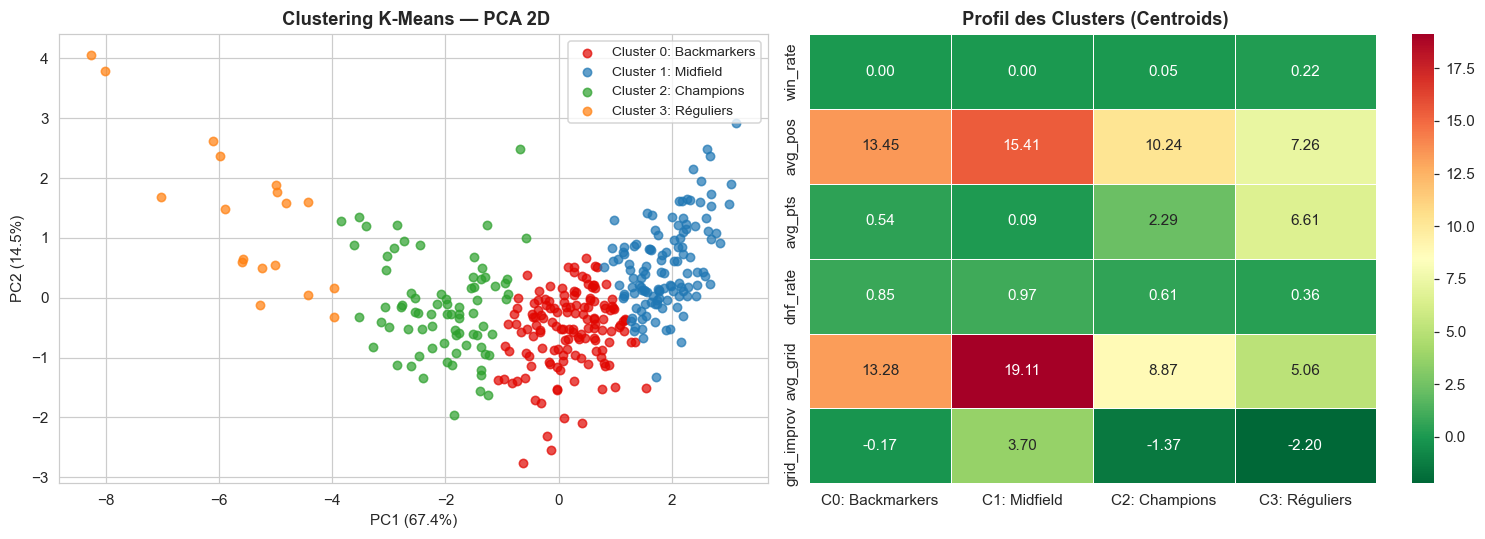


=== EXEMPLES DE PILOTES PAR CLUSTER ===

Cluster 0 — Backmarkers: ['René Arnoux', 'Jacques Laffite', 'Riccardo Patrese', 'John Watson', 'Michele Alboreto']

Cluster 1 — Midfield: ['Adrián Campos', 'Aguri Suzuki', 'Alex Caffi', 'Alex Ribeiro', 'Alex Yoong']

Cluster 2 — Champions: ['Fernando Alonso', 'Nigel Mansell', 'Niki Lauda', 'Nelson Piquet', 'Kimi Räikkönen']

Cluster 3 — Réguliers: ['Lewis Hamilton', 'Michael Schumacher', 'Max Verstappen', 'Sebastian Vettel', 'Alain Prost']


In [18]:
K_FINAL = 4
km_final = KMeans(n_clusters=K_FINAL, n_init=10, random_state=42)
cluster_labels = km_final.fit_predict(X_cluster_scaled)
driver_profiles['cluster'] = cluster_labels

# PCA 2D
pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_cluster_scaled)

cluster_names = {0:'Backmarkers', 1:'Midfield', 2:'Champions', 3:'Réguliers'}
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for cl in range(K_FINAL):
    mask = cluster_labels == cl
    axes[0].scatter(X_2d[mask,0], X_2d[mask,1], label=f'Cluster {cl}: {cluster_names.get(cl,"")}',
                    alpha=0.7, s=30, color=COLORS[cl])
axes[0].set_title(' Clustering K-Means — PCA 2D', fontweight='bold')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
axes[0].legend(fontsize=9)

# Heatmap des centroids
centroids_df = pd.DataFrame(
    scaler_c.inverse_transform(km_final.cluster_centers_),
    columns=CLUSTER_FEATURES,
    index=[f'C{i}: {cluster_names.get(i,"")}' for i in range(K_FINAL)]
)
sns.heatmap(centroids_df.T, annot=True, fmt='.2f', cmap='RdYlGn_r', ax=axes[1], linewidths=0.5)
axes[1].set_title(' Profil des Clusters (Centroids)', fontweight='bold')

plt.tight_layout()
plt.show()

# Quelques pilotes par cluster
print("\n=== EXEMPLES DE PILOTES PAR CLUSTER ===")
for cl in range(K_FINAL):
    top = driver_profiles[driver_profiles['cluster']==cl].sort_values('wins', ascending=False).head(5)
    print(f"\nCluster {cl} — {cluster_names.get(cl,'')}: {list(top.index)}")

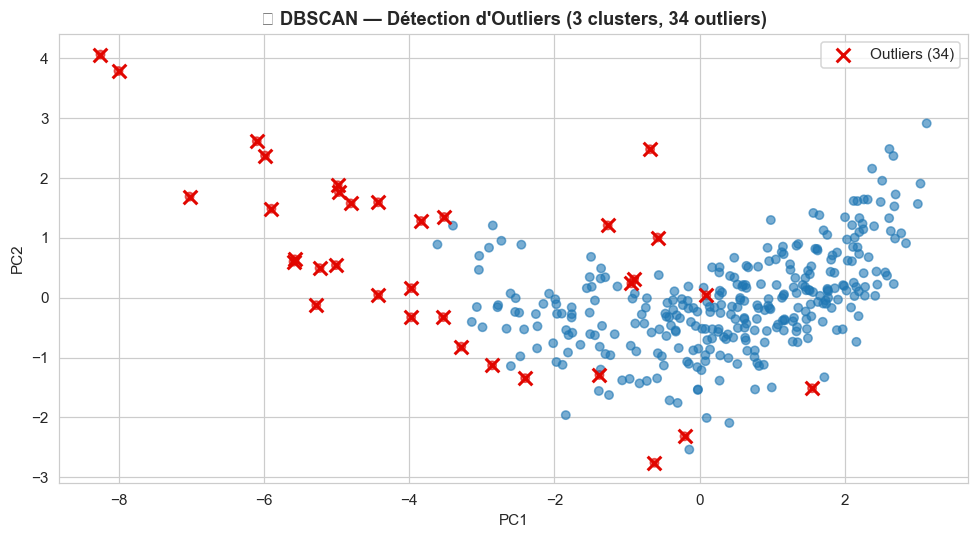

 Pilotes outliers (statistiquement atypiques) :
                    races  wins    avg_pos  win_rate  dnf_rate
driver_name                                                   
Lewis Hamilton        383   105   5.232376  0.274151  0.125326
Michael Schumacher    308    91   6.879870  0.295455  0.288961
Max Verstappen        236    71   5.500000  0.300847  0.173729
Sebastian Vettel      300    53   7.093333  0.176667  0.246667
Alain Prost           202    51   7.504950  0.252475  0.410891
Ayrton Senna          161    41   8.136646  0.254658  0.472050
Fernando Alonso       431    32   8.744780  0.074246  0.354988
Nigel Mansell         190    31  11.089474  0.163158  0.636842
Jackie Stewart        100    27   7.410000  0.270000  0.500000
Jim Clark              73    25   7.095890  0.342466  0.561644


In [19]:
dbscan = DBSCAN(eps=0.8, min_samples=5)
db_labels = dbscan.fit_predict(X_cluster_scaled)

n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise    = (db_labels == -1).sum()

fig, ax = plt.subplots(figsize=(9, 5))
colors_db = [COLORS[0] if l == -1 else COLORS[1] for l in db_labels]
ax.scatter(X_2d[:,0], X_2d[:,1], c=colors_db, alpha=0.6, s=30)
ax.scatter(X_2d[db_labels==-1,0], X_2d[db_labels==-1,1],
           color=COLORS[0], s=80, marker='x', linewidths=2, label=f'Outliers ({n_noise})', zorder=5)
ax.set_title(f'🔍 DBSCAN — Détection d\'Outliers ({n_clusters} clusters, {n_noise} outliers)', fontweight='bold')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.legend()
plt.tight_layout()
plt.show()

outlier_drivers = driver_profiles[db_labels == -1].sort_values('wins', ascending=False)
print(f" Pilotes outliers (statistiquement atypiques) :")
print(outlier_drivers[['races','wins','avg_pos','win_rate','dnf_rate']].head(10).to_string())

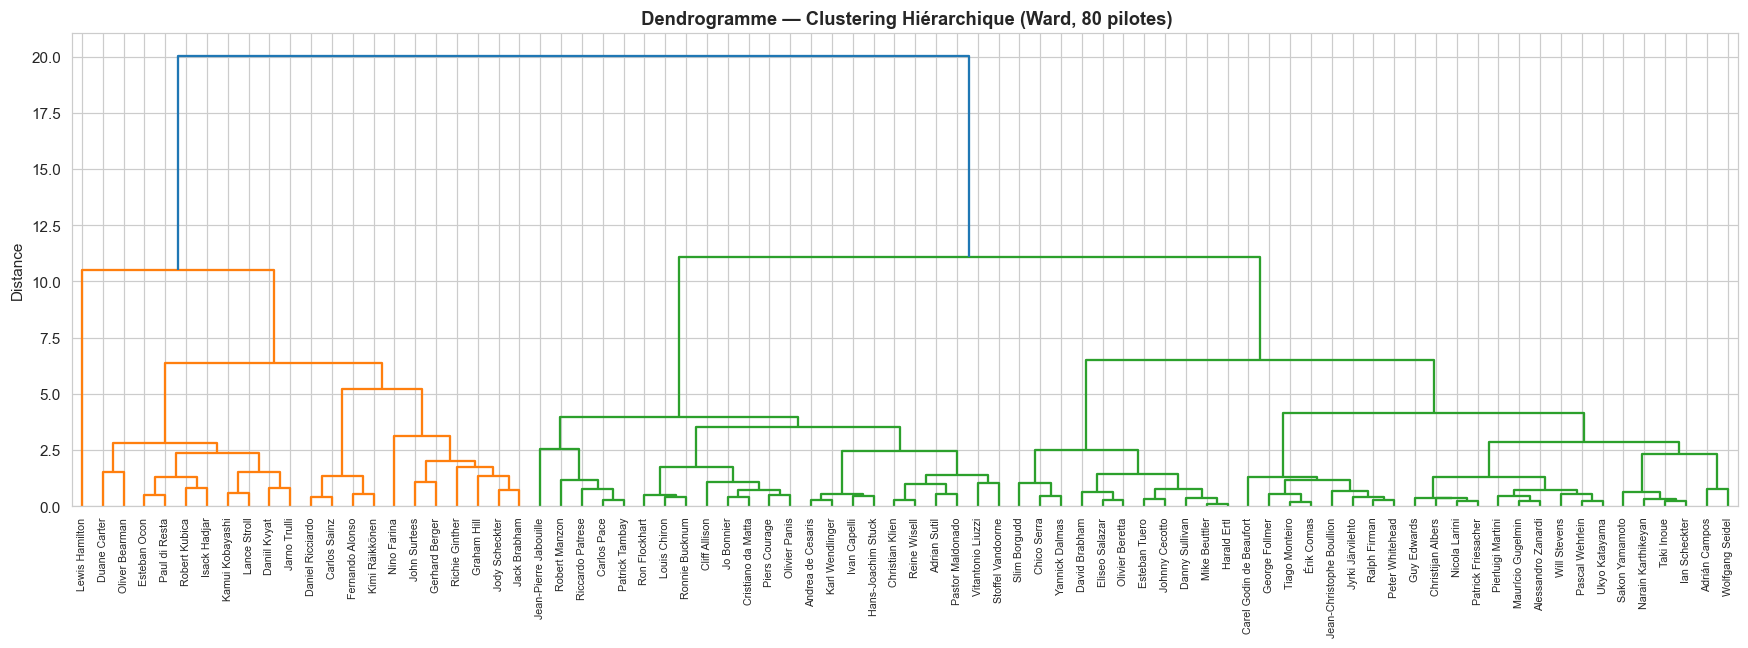

In [20]:
sample_idx = np.random.choice(len(X_cluster_scaled), min(80, len(X_cluster_scaled)), replace=False)
X_sample   = X_cluster_scaled[sample_idx]
names_sample = driver_profiles.index[sample_idx].tolist()

linked = linkage(X_sample, method='ward')

fig, ax = plt.subplots(figsize=(16, 6))
dendrogram(linked, labels=names_sample, ax=ax, leaf_rotation=90, leaf_font_size=7,
           color_threshold=0.7*max(linked[:,2]))
ax.set_title(' Dendrogramme — Clustering Hiérarchique (Ward, 80 pilotes)', fontweight='bold')
ax.set_ylabel('Distance')
plt.tight_layout()
plt.show()

## 9. Predictions F1 2026 — Résultats & Classement

> Le modèle est **entraine sur 1950–2025** et fait ses prédictions sur les 3 courses 2026 déjà disputées,
> puis extrapole le classement championnat.


In [21]:
X_2026_raw    = df_2026[FEATURE_COLS].fillna(df_2026[FEATURE_COLS].median())
X_2026_scaled = scaler.transform(X_2026_raw)

best_clf = clf_results['Random Forest']['model']
best_reg = reg_results['Random Forest Regressor']['model']

df_2026 = df_2026.copy()
df_2026['pred_win_prob']    = best_clf.predict_proba(X_2026_scaled)[:,1]
df_2026['pred_position']    = best_reg.predict(X_2026_scaled).round(1)

print("=== PRÉDICTIONS PAR COURSE 2026 ===\n")
for race in df_2026['race_name'].unique():
    race_df = df_2026[df_2026['race_name']==race].sort_values('position')
    print(f"{'─'*65}")
    print(f"  {race}")
    print(f"{'─'*65}")
    print(f"  {'Pilote':<28} {'Pos Réelle':>10} {'Pos Prédite':>12} {'P(Win)':>8}")
    print(f"  {'─'*58}")
    for _, row in race_df.head(10).iterrows():
        print(f"  {row['driver_name']:<28} {int(row['position']):>10} {row['pred_position']:>12.1f} {row['pred_win_prob']:>8.1%}")
    print()

=== PRÉDICTIONS PAR COURSE 2026 ===

─────────────────────────────────────────────────────────────────
  Australian Grand Prix
─────────────────────────────────────────────────────────────────
  Pilote                       Pos Réelle  Pos Prédite   P(Win)
  ──────────────────────────────────────────────────────────
  George Russell                        1          1.0    93.5%
  Andrea Kimi Antonelli                 2          2.0     8.0%
  Charles Leclerc                       3          3.0     0.0%
  Lewis Hamilton                        4          4.0     3.0%
  Lando Norris                          5          5.0     0.0%
  Max Verstappen                        6          5.9     2.0%
  Oliver Bearman                        7          7.0     0.0%
  Arvid Lindblad                        8          8.0     0.0%
  Gabriel Bortoleto                     9          9.0     0.0%
  Pierre Gasly                         10         10.0     0.0%

─────────────────────────────────────────

In [27]:
champ_actual = df_2026.groupby('driver_name').agg(
    actual_pts   = ('points', 'sum'),
    avg_win_prob = ('pred_win_prob', 'mean'),
    avg_pred_pos = ('pred_position', 'mean')
).sort_values('actual_pts', ascending=False).reset_index()

champ_actual['rank'] = range(1, len(champ_actual)+1)

print("╔═════════════════════════════════════════════════════════════════╗")
print("║        🏆 CLASSEMENT CHAMPIONNAT 2026 (3 courses)               ║ " )
print("╠═════════════════════════════════════════════════════════════════╣")
print(f"  {'#':>3}  {'Pilote':<28} {'Pts':>6}  {'P(Win)%':>8}  {'Pos Moy':>8}")
print(f"  {'─'*58}")
for _, row in champ_actual.iterrows():
    medal = '🥇' if row['rank']==1 else '🥈' if row['rank']==2 else '🥉' if row['rank']==3 else '  '
    print(f"  {medal} {int(row['rank']):>2}.  {row['driver_name']:<28} {row['actual_pts']:>5.0f}  {row['avg_win_prob']:>8.1%}  {row['avg_pred_pos']:>8.1f}")
print("╚═════════════════════════════════════════════════════════════════╝")

╔═════════════════════════════════════════════════════════════════╗
║        🏆 CLASSEMENT CHAMPIONNAT 2026 (3 courses)               ║ 
╠═════════════════════════════════════════════════════════════════╣
    #  Pilote                          Pts   P(Win)%   Pos Moy
  ──────────────────────────────────────────────────────────
  🥇  1.  Andrea Kimi Antonelli           68     59.0%       1.3
  🥈  2.  George Russell                  55     39.3%       2.3
  🥉  3.  Charles Leclerc                 42      0.0%       3.3
      4.  Lewis Hamilton                  35      2.0%       4.3
      5.  Lando Norris                    20      0.3%      10.0
      6.  Oscar Piastri                   18      2.0%      14.0
      7.  Oliver Bearman                  16      0.0%      11.3
      8.  Pierre Gasly                    15      0.0%       7.7
      9.  Max Verstappen                  12      1.2%      10.0
     10.  Liam Lawson                      8      0.0%       9.7
     11.  Isack Hadjar   

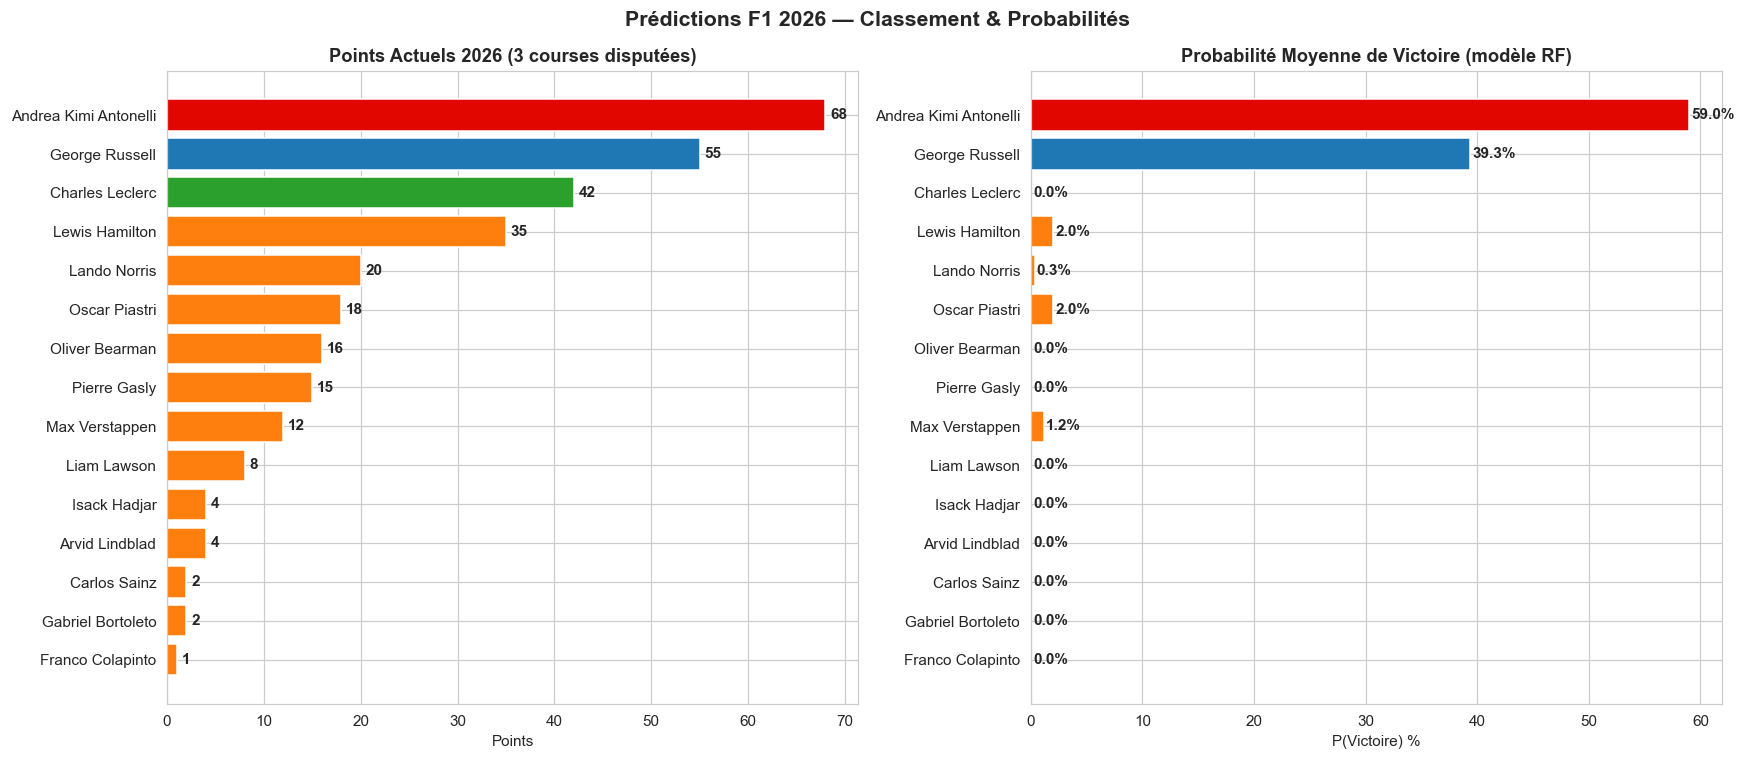

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle(' Prédictions F1 2026 — Classement & Probabilités', fontsize=14, fontweight='bold')

top15 = champ_actual.head(15)
colors_bar = [COLORS[0], COLORS[1], COLORS[2]] + [COLORS[3]] * 12
axes[0].barh(top15['driver_name'][::-1], top15['actual_pts'][::-1], color=colors_bar[::-1])
axes[0].set_title('Points Actuels 2026 (3 courses disputées)', fontweight='bold')
axes[0].set_xlabel('Points')
for i, (pts, name) in enumerate(zip(top15['actual_pts'][::-1], top15['driver_name'][::-1])):
    axes[0].text(pts + 0.5, i, f'{int(pts)}', va='center', fontweight='bold')

axes[1].barh(top15['driver_name'][::-1], top15['avg_win_prob'][::-1] * 100, color=colors_bar[::-1])
axes[1].set_title('Probabilité Moyenne de Victoire (modèle RF)', fontweight='bold')
axes[1].set_xlabel('P(Victoire) %')
for i, (p, name) in enumerate(zip(top15['avg_win_prob'][::-1], top15['driver_name'][::-1])):
    axes[1].text(p*100 + 0.2, i, f'{p:.1%}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [32]:
# ── 9.4 Résumé final des performances des modèles ────────────
print("\n" + "="*65)
print("            RESUME FINAL — PERFORMANCES DES MODELES")
print("="*65)

print("\n CLASSIFICATION (Prédire le gagnant) :")
print(f"  {'Modèle':<24} {'F1':>6} {'AUC':>6} {'CV-AUC':>8}")
print(f"  {'─'*46}")
for name, res in clf_results.items():
    best_mark = ' ⭐' if res['auc'] == max(r['auc'] for r in clf_results.values()) else ''
    print(f"  {name:<24} {res['f1']:>6.3f} {res['auc']:>6.3f} {res['cv_auc']:>8.3f}{best_mark}")

print("\n RÉGRESSION (Prédire la position) :")
print(f"  {'Modèle':<26} {'MAE':>6} {'RMSE':>7} {'R²':>6}")
print(f"  {'─'*47}")
for name, res in reg_results.items():
    best_mark = ' ⭐' if res['r2'] == max(r['r2'] for r in reg_results.values()) else ''
    print(f"  {name:<26} {res['mae']:>6.2f} {res['rmse']:>7.2f} {res['r2']:>6.3f}{best_mark}")

print("\n  CLUSTERING :")
sil = silhouette_score(X_cluster_scaled, cluster_labels)
print(f"  K-Means (K=4)     : Silhouette = {sil:.3f}")
print(f"  DBSCAN            : {n_noise} outliers détectés sur {len(X_cluster)} pilotes")
print(f"  Hiérarchique Ward : Dendrogramme sur 80 pilotes")

print("\n" + "="*65)


            RESUME FINAL — PERFORMANCES DES MODELES

 CLASSIFICATION (Prédire le gagnant) :
  Modèle                       F1    AUC   CV-AUC
  ──────────────────────────────────────────────
  Decision Tree             0.752  0.995    0.993
  KNN                       0.553  0.967    0.961
  Random Forest             0.923  0.998    0.999
  AdaBoost                  0.844  0.993    0.992
  Logistic Regression       0.744  1.000    1.000 ⭐

 RÉGRESSION (Prédire la position) :
  Modèle                        MAE    RMSE     R²
  ───────────────────────────────────────────────
  Ridge Regression             0.00    0.00  1.000 ⭐
  Decision Tree Regressor      1.08    1.57  0.948
  Random Forest Regressor      0.07    0.28  0.998

  CLUSTERING :
  K-Means (K=4)     : Silhouette = 0.315
  DBSCAN            : 34 outliers détectés sur 356 pilotes
  Hiérarchique Ward : Dendrogramme sur 80 pilotes

